In [1]:
# -*- coding: utf-8 -*-
"""
Option Pricing and FOMC Analysis
Data Configuration and Processing Module
"""

import pandas as pd
import numpy as np
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)

# =============================================================================
# Data Loading
# =============================================================================

options_data = pd.read_parquet('data/raw/spx_vol_surface_daily_1996_2025.parquet')
fomc_comms = pd.read_csv('data/raw/communications.csv')
fomc_base = pd.read_stata('data/raw/fomc_data_base.dta')
vix_data = pd.read_csv('data/raw/CBOE Volatility Index Historical Data.csv')
mps_data = pd.read_excel('data/raw/monetary policy shock.xlsx')
rf_data = pd.read_csv('data/raw/interest rate.csv')
spx_data = pd.read_csv('data/raw/S&P 500.csv')

# =============================================================================
# Data Processing
# =============================================================================

# FOMC dates
fomc_comms_clean = fomc_comms[fomc_comms['Type'] == 'Statement'].copy()
fomc_comms_clean['Date'] = pd.to_datetime(fomc_comms_clean['Date'])
fomc_base['date'] = pd.to_datetime(fomc_base['date'])

# Combine FOMC dates and correct 2008-08-08 to 2008-08-05
all_fomc_dates = pd.concat([
    fomc_base[fomc_base['fomc'] == 1]['date'],
    fomc_comms_clean['Date']
]).drop_duplicates().sort_values().reset_index(drop=True)

if pd.Timestamp('2008-08-08') in all_fomc_dates.values:
    all_fomc_dates = all_fomc_dates[all_fomc_dates != pd.Timestamp('2008-08-08')]
if pd.Timestamp('2008-08-05') not in all_fomc_dates.values:
    all_fomc_dates = pd.concat([all_fomc_dates, pd.Series([pd.Timestamp('2008-08-05')])]).drop_duplicates().sort_values()

if pd.Timestamp('2019-10-04') in all_fomc_dates.values:
    all_fomc_dates = all_fomc_dates[all_fomc_dates != pd.Timestamp('2019-10-04')]
if pd.Timestamp('2019-10-11') not in all_fomc_dates.values:
    all_fomc_dates = pd.concat([all_fomc_dates, pd.Series([pd.Timestamp('2019-10-11')])]).drop_duplicates().sort_values()

fomc_date_df = pd.DataFrame({'Date': all_fomc_dates, 'fomc_dummy': 1})

# Market data processing
vix_data['Date'] = pd.to_datetime(vix_data['Date'], format='%m/%d/%Y')
vix_data = vix_data.rename(columns={'Price': 'vix'})[['Date', 'vix']]

rf_data['Date'] = pd.to_datetime(rf_data['Time Period'])
rf_data['rf_rate'] = pd.to_numeric(rf_data['interest rate'], errors='coerce')
rf_data['rf_rate'] = rf_data['rf_rate'].interpolate(method='linear')
rf_data = rf_data[['Date', 'rf_rate']]

spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')
spx_data['spx_price'] = spx_data['Price'].str.replace(',', '').astype(float)
spx_data = spx_data[['Date', 'spx_price']]

mps_data['Date'] = pd.to_datetime(mps_data['Date'])
mps_data = mps_data[['Date', 'MPS']].rename(columns={'MPS': 'monetary_policy_shock'})

# Options data filtering
target_maturities = [30, 91, 182, 365]
options_data_filtered = options_data[options_data['days'].isin(target_maturities)].copy()
options_data_filtered['date'] = pd.to_datetime(options_data_filtered['date'])

# =============================================================================
# MPS Date Adjustment Function
# =============================================================================

def adjust_mps_dates(fomc_dates, mps_data, max_days_diff=1):
    """
    Adjust MPS dates to match FOMC meeting dates within specified tolerance
    """
    mps_adjusted = mps_data.copy()
    adjustments = []
    
    for fomc_date in fomc_dates:
        existing_mps = mps_data[mps_data['Date'] == fomc_date]
        
        if len(existing_mps) == 0:
            for days_diff in range(1, max_days_diff + 1):
                # Check previous day
                prev_date = fomc_date - pd.Timedelta(days=days_diff)
                prev_mps = mps_data[mps_data['Date'] == prev_date]
                if len(prev_mps) > 0:
                    mps_value = prev_mps['monetary_policy_shock'].iloc[0]
                    adjustments.append((prev_date, fomc_date, -days_diff, mps_value))
                    mps_adjusted = pd.concat([mps_adjusted, pd.DataFrame([{
                        'Date': fomc_date, 'monetary_policy_shock': mps_value
                    }])], ignore_index=True)
                    break
                
                # Check next day
                next_date = fomc_date + pd.Timedelta(days=days_diff)
                next_mps = mps_data[mps_data['Date'] == next_date]
                if len(next_mps) > 0:
                    mps_value = next_mps['monetary_policy_shock'].iloc[0]
                    adjustments.append((next_date, fomc_date, days_diff, mps_value))
                    mps_adjusted = pd.concat([mps_adjusted, pd.DataFrame([{
                        'Date': fomc_date, 'monetary_policy_shock': mps_value
                    }])], ignore_index=True)
                    break
    
    if adjustments:
        print(f"MPS Date Adjustments ({len(adjustments)} cases):")
        for orig, new, diff, val in adjustments:
            print(f"  {orig.strftime('%Y-%m-%d')} -> {new.strftime('%Y-%m-%d')} (diff={diff}, MPS={val:.4f})")
    
    return mps_adjusted

# =============================================================================
# Data Merging
# =============================================================================

panel_data = options_data_filtered.rename(columns={'date': 'Date'})
panel_data = panel_data.merge(fomc_date_df, on='Date', how='left')
panel_data['fomc_dummy'] = panel_data['fomc_dummy'].fillna(0)

# Adjust MPS dates
print("Adjusting MPS dates...")
fomc_dates = panel_data[panel_data['fomc_dummy'] == 1]['Date'].unique()
adjusted_mps_data = adjust_mps_dates(fomc_dates, mps_data)

# Merge market data
panel_data = panel_data.merge(vix_data, on='Date', how='left')
panel_data = panel_data.merge(rf_data, on='Date', how='left')
panel_data = panel_data.merge(spx_data, on='Date', how='left')
panel_data = panel_data.merge(adjusted_mps_data, on='Date', how='left')

# =============================================================================
# Final Calculations
# =============================================================================

panel_data['T_years'] = panel_data['days'] / 365
panel_data['dividend_yield'] = 0.0
panel_data['forwardprice'] = panel_data['spx_price'] * np.exp(
    panel_data['rf_rate']/100 * panel_data['T_years']
)

vix_75 = vix_data['vix'].quantile([0.75]).iloc[0]
panel_data['vix_stress_75'] = (panel_data['vix'] >= vix_75).astype(int)

# Filter date range
panel_data = panel_data[
    (panel_data['Date'] >= '1996-01-04') & 
    (panel_data['Date'] <= '2023-08-31')
]

# =============================================================================
# Matching Analysis
# =============================================================================

print("\nFOMC-MPS MATCHING ANALYSIS")
print("=" * 40)

unique_fomc_dates = panel_data[panel_data['fomc_dummy'] == 1]['Date'].unique()
fomc_days = panel_data[panel_data['fomc_dummy'] == 1]

fomc_no_mps = fomc_days[fomc_days['monetary_policy_shock'].isna()]
fomc_with_mps = fomc_days[fomc_days['monetary_policy_shock'].notna()]

fomc_no_mps_dates = fomc_no_mps['Date'].unique()
fomc_with_mps_dates = fomc_with_mps['Date'].unique()

print(f"Total FOMC meetings in sample: {len(unique_fomc_dates)}")
print(f"FOMC meetings with MPS data: {len(fomc_with_mps_dates)}")
print(f"FOMC meetings without MPS data: {len(fomc_no_mps_dates)}")
print(f"Match rate: {len(fomc_with_mps_dates)/len(unique_fomc_dates)*100:.1f}%")

if len(fomc_no_mps_dates) > 0:
    print("\nRemaining unmatched FOMC dates:")
    for date in sorted(fomc_no_mps_dates):
        print(f"  - {date.strftime('%Y-%m-%d')}")

# =============================================================================
# Save and Summary
# =============================================================================

panel_data.to_parquet('data/processed/options_fomc_panel_1996_2023.parquet', index=False)

print("\nDESCRIPTIVE STATISTICS")
print("=" * 40)

# Define variables for descriptive statistics with LaTeX-friendly names
latex_vars = {
    'impl_volatility': 'Implied Volatility',
    'impl_strike': 'Strike Price',
    'delta': 'Delta',
    'days': 'Days to Maturity',
    'vix': 'VIX',
    'rf_rate': 'Risk-Free Rate (\\%)',
    'spx_price': 'S\\&P 500 Price',
    'monetary_policy_shock': 'Monetary Policy Shock',
    'forwardprice': 'Forward Price'
}

# Filter available variables
available_vars = [var for var in latex_vars.keys() if var in panel_data.columns]

# Generate descriptive statistics
desc_stats = panel_data[available_vars].describe().round(4)

# Rename columns for LaTeX output
desc_stats_latex = desc_stats.rename(columns=latex_vars)

# Convert to LaTeX format
latex_code = desc_stats_latex.to_latex(
    caption="Descriptive Statistics of Key Variables",
    label="tab:descriptive_stats",
    position='htbp',
    float_format="%.4f"
)

print("LaTeX code for descriptive statistics table:")
print(latex_code)

# Save LaTeX table to file
with open('data/processed/descriptive_statistics.tex', 'w') as f:
    f.write(latex_code)

# Generate sample statistics for LaTeX
sample_start = panel_data['Date'].min().strftime('%Y-%m-%d')
sample_end = panel_data['Date'].max().strftime('%Y-%m-%d')
total_obs = f"{len(panel_data):,}"
unique_dates = panel_data['Date'].nunique()
fomc_obs = f"{panel_data['fomc_dummy'].sum():,}"
unique_fomc_dates = panel_data[panel_data['fomc_dummy'] == 1]['Date'].nunique()

# Create LaTeX code for sample statistics
sample_latex = f"""
% Sample Statistics for Paper
\\begin{{table}}[htbp]
\\centering
\\caption{{Sample Characteristics}}
\\label{{tab:sample_stats}}
\\begin{{tabular}}{{lc}}
\\toprule
Statistic & Value \\\\
\\midrule
Sample Period & {sample_start} to {sample_end} \\\\
Total Observations & {total_obs} \\\\
Unique Dates & {unique_dates:,} \\\\
FOMC Observations & {fomc_obs} \\\\
Unique FOMC Dates & {unique_fomc_dates} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""

print("\nLaTeX code for sample statistics table:")
print(sample_latex)

# Save sample statistics to file
with open('data/processed/sample_statistics.tex', 'w') as f:
    f.write(sample_latex)

print(f"\nSample period: {sample_start} to {sample_end}")
print(f"Total observations: {total_obs}")
print(f"Unique dates: {unique_dates:,}")
print(f"FOMC observations: {fomc_obs}")
print(f"Unique FOMC dates: {unique_fomc_dates}")
print(f"Data saved to: data/processed/options_fomc_panel_1996_2023.parquet")
print(f"LaTeX tables saved to: data/processed/descriptive_statistics.tex and data/processed/sample_statistics.tex")

Adjusting MPS dates...
MPS Date Adjustments (7 cases):
  2007-08-17 -> 2007-08-16 (diff=1, MPS=-0.0281)
  2008-03-11 -> 2008-03-10 (diff=1, MPS=0.0899)
  2008-10-08 -> 2008-10-07 (diff=1, MPS=0.0166)
  2009-03-18 -> 2009-03-17 (diff=1, MPS=-0.0581)
  2009-08-12 -> 2009-08-11 (diff=1, MPS=-0.0060)
  2009-09-23 -> 2009-09-22 (diff=1, MPS=-0.0986)
  2009-12-16 -> 2009-12-15 (diff=1, MPS=0.0151)

FOMC-MPS MATCHING ANALYSIS
Total FOMC meetings in sample: 234
FOMC meetings with MPS data: 233
FOMC meetings without MPS data: 1
Match rate: 99.6%

Remaining unmatched FOMC dates:
  - 2001-09-17

DESCRIPTIVE STATISTICS
LaTeX code for descriptive statistics table:
\begin{table}[htbp]
\caption{Descriptive Statistics of Key Variables}
\label{tab:descriptive_stats}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & Implied Volatility & Strike Price & Delta & Days to Maturity & VIX & Risk-Free Rate (\%) & S\&P 500 Price & Monetary Policy Shock & Forward Price \\
\midrule
count & 946968.0000 & 946968.0000 & 946968

In [2]:
import pyarrow.parquet as pq

table = pq.read_table('data/processed/options_fomc_panel_1996_2023.parquet')

df = table.to_pandas()

print(df.head())

      secid       Date cp_flag  delta  days  impl_volatility  impl_premium  \
0  108105.0 1996-01-04       C   10.0  30.0         0.096883      0.803134   
1  108105.0 1996-01-04       C   15.0  30.0         0.098895      1.343892   
2  108105.0 1996-01-04       C   20.0  30.0         0.100675      1.963859   
3  108105.0 1996-01-04       C   25.0  30.0         0.101514      2.643503   
4  108105.0 1996-01-04       C   30.0  30.0         0.102137      3.392095   

   impl_strike  fomc_dummy    vix  rf_rate  spx_price  monetary_policy_shock  \
0     642.7569         0.0  13.78     5.19      617.7                    NaN   
1     638.7863         0.0  13.78     5.19      617.7                    NaN   
2     635.5488         0.0  13.78     5.19      617.7                    NaN   
3     632.5961         0.0  13.78     5.19      617.7                    NaN   
4     629.8998         0.0  13.78     5.19      617.7                    NaN   

    T_years  dividend_yield  forwardprice  vix_str

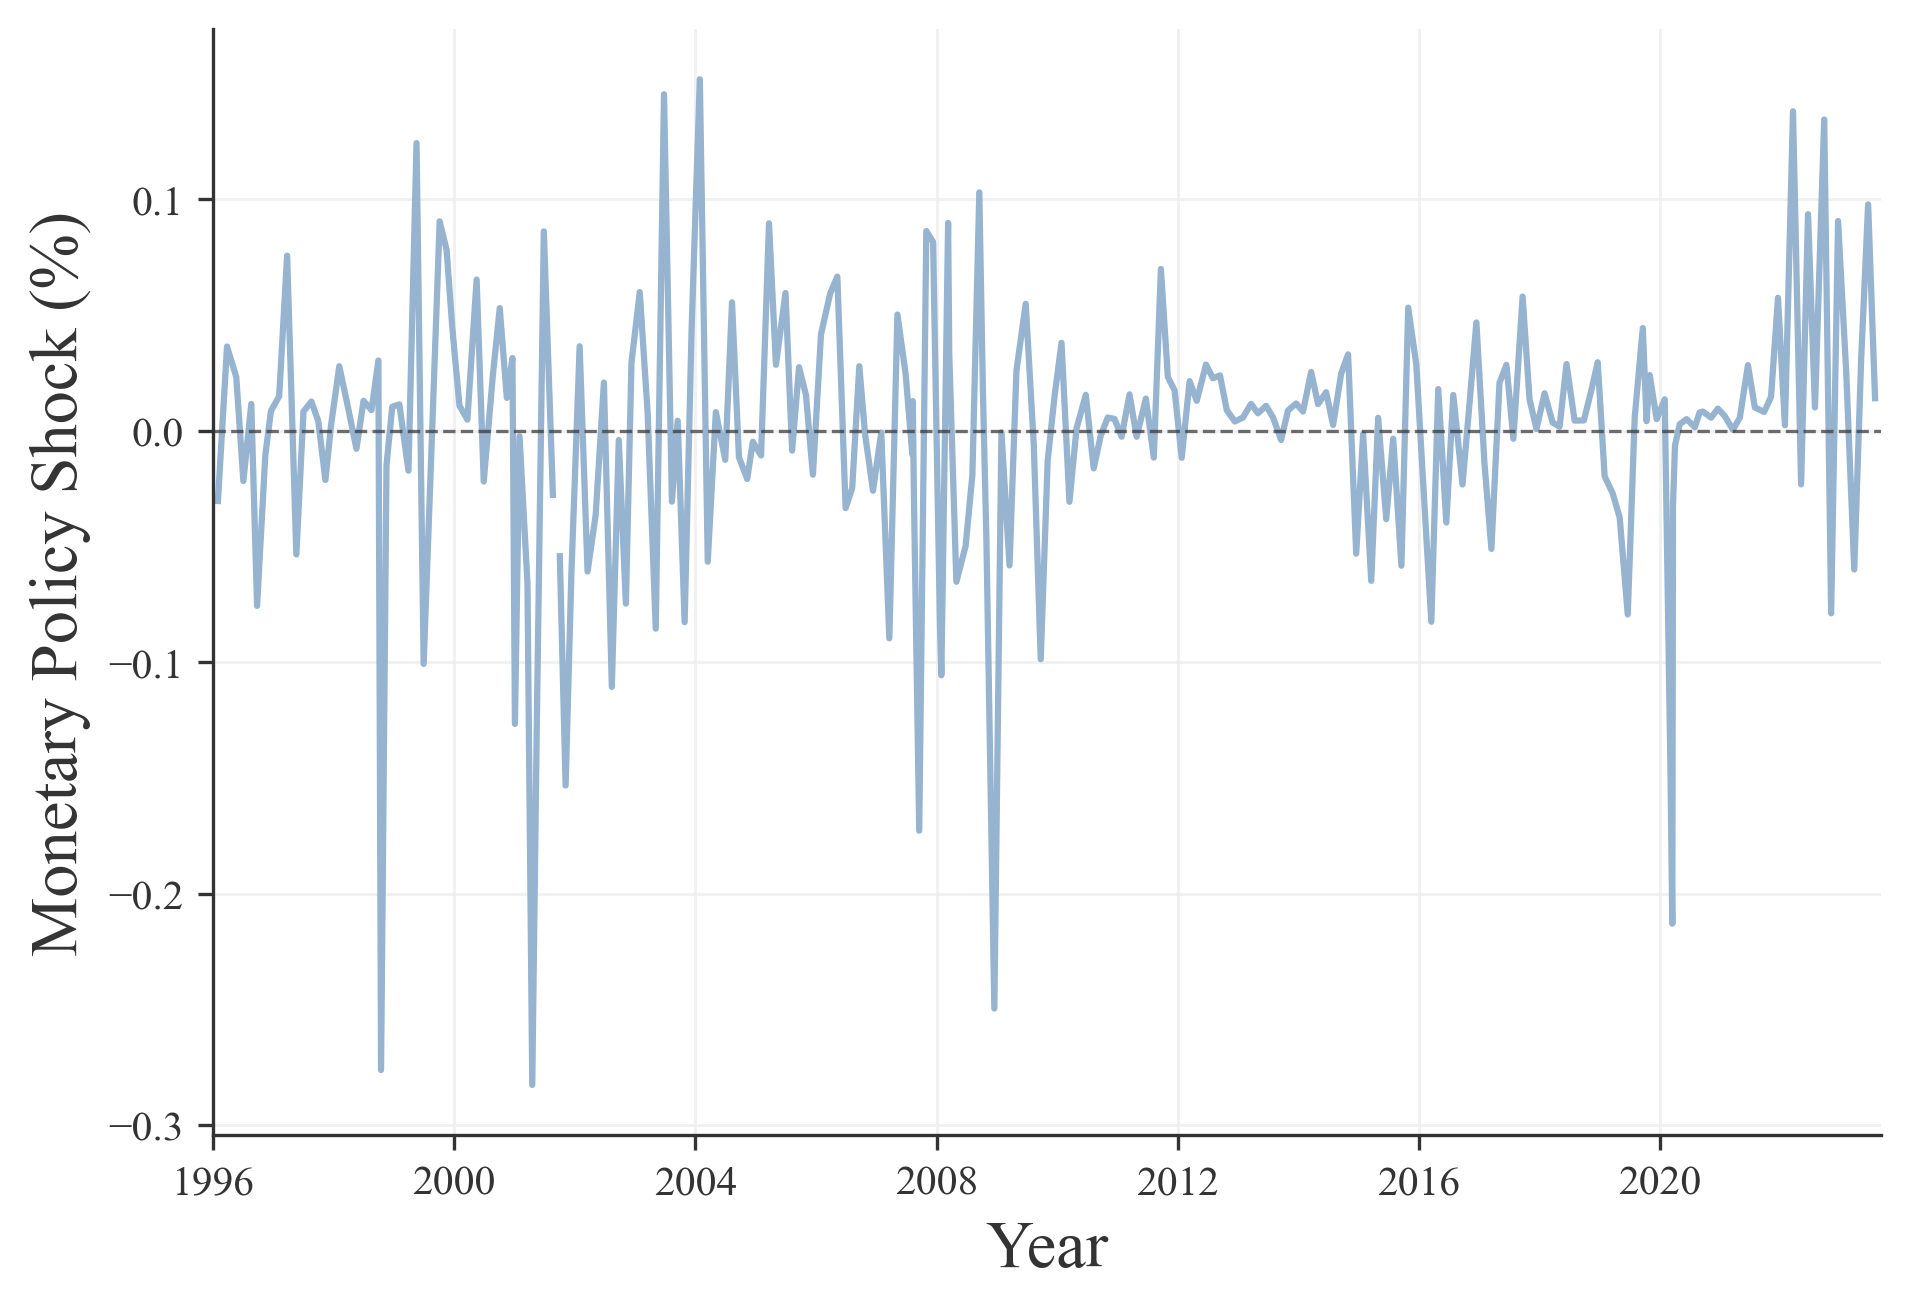

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib import rcParams

def set_academic_style():
    rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 11,
        'mathtext.fontset': 'stix',
        'figure.figsize': (6.5, 4.5),
        'figure.dpi': 300,
        'axes.linewidth': 0.8,
        'axes.edgecolor': '#333333',
        'axes.labelcolor': '#333333',
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.color': '#333333',
        'ytick.color': '#333333',
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'legend.frameon': True,
        'legend.framealpha': 0.9,
        'legend.edgecolor': '#DDDDDD',
        'grid.color': '#EEEEEE',
        'grid.linestyle': '-',
        'grid.linewidth': 0.7,
        'grid.alpha': 0.8,
        'lines.linewidth': 1.5,
        'lines.markersize': 4,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'savefig.format': 'pdf'
    })

PANTONE_COLORS = {
    'ultra_violet_2018': '#5F4B8B',
    'peach_fuzz_2024': '#FFBE98',
    'soft_teal': '#7A9E9F',
    'dusty_lavender': '#B8A9C9',
    'warm_sand': '#D7CEC7',
    'pale_moss': '#C8D5B9',
    'misty_blue': '#96B3D0'
}

# Set academic style
set_academic_style()

# Create results directory
os.makedirs('results', exist_ok=True)

# Load and process data
mps_data = pd.read_excel('data/raw/monetary policy shock.xlsx')
mps_data = mps_data[['Date', 'MPS']].rename(columns={'MPS': 'monetary_policy_shock'})
mps_data['Date'] = pd.to_datetime(mps_data['Date'])

# Filter data for 1996-2023.8
start_date = '1996-01-01'
end_date = '2023-08-31'
mps_data = mps_data[(mps_data['Date'] >= start_date) & (mps_data['Date'] <= end_date)]

# Create plot with academic style
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Plot time series
ax.plot(mps_data['Date'], mps_data['monetary_policy_shock'], 
        color=PANTONE_COLORS['misty_blue'], 
        linewidth=1.5,
        label='Monetary Policy Shock')

# Set labels and title
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Monetary Policy Shock (%)', fontsize=16)

# Set x-axis limits
ax.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# Add grid and customize
ax.grid(True, alpha=0.8, color='#EEEEEE', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)

# Add zero line for reference
ax.axhline(y=0, color='#333333', linewidth=0.8, alpha=0.7, linestyle='--')

# Adjust layout and save
plt.tight_layout()
plt.savefig('results/monetary_policy_shock.png', dpi=300)  # Also save as PNG
plt.show()